In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [3]:
# Plot single RB decay and fit to model
def plot_data_fit(df, model_func, popt):
    plt.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="P00", color=gs.get_color(0))
    #plt.errorbar(df["Clifford Length"], df["P01"], yerr=df["P01 Std"], fmt="^", label="P01", color=gs.get_color(1))
    #plt.errorbar(df["Clifford Length"], df["P10"], yerr=df["P10 Std"], fmt="^", label="P10", color=gs.get_color(2))
    plt.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="P11", color=gs.get_color(3))
    P0110 = df["P01"] + df["P10"]
    P0110_std = np.sqrt(df["P01 Std"]**2 + df["P10 Std"]**2)
    plt.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="P01+P10", color=gs.get_color(4))

    x_fit = np.linspace(min(df["Clifford Length"]), max(df["Clifford Length"]), 100)
    P_fit = model_func(x_fit, *popt).reshape(4, -1)
    plt.plot(x_fit, P_fit[0], color=gs.get_color(0), alpha=gs.get_alpha(), linestyle="-")
    #plt.plot(x_fit, P_fit[1], color=gs.get_color(1), alpha=gs.get_alpha())
    #plt.plot(x_fit, P_fit[2], color=gs.get_color(2), alpha=gs.get_alpha())
    plt.plot(x_fit, P_fit[3], color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
    P0110_fit = P_fit[1] + P_fit[2]
    plt.plot(x_fit, P0110_fit, color=gs.get_color(4), alpha=gs.get_alpha(), linestyle="-")
    # log x
    plt.xscale("log")

    plt.xlabel("Clifford Length")
    plt.ylabel("Population")
    plt.legend()
    plt.show()

def plot_data_fit(ax, df, m, popt):
    x_min = 0.5
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 1.2
    if m.name == "GT" or m.name == "PTM" or m.name == "Clifford" or m.name == "SO3":
        reshape_fac = 4
        ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

        ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8, markersize=2)
        ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="$\\mathcal{P}_{DD}$", color="#017517", alpha=0.8, markersize=2)
        P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
        P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
        ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="$\\mathcal{P}_{SD}+\\mathcal{P}_{DS}$", color=gs.get_color(3), alpha=0.8, markersize=2)
        x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
        ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
        P0110_fit = P_fit[1] + P_fit[2]
        ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
        ax.set_ylabel("Pops.")
        # turn off legend for this subplot
        ax.legend().set_visible(False)

    elif m.name == "GTRed":
        reshape_fac = 3
        ax.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
        pops = [df["P00"], df["P01"], df["P10"], df["P11"]]
        errs = [df["P00 Std"], df["P01 Std"], df["P10 Std"], df["P11 Std"]]
        pops, errs = m.convert_pops(pops, errs)
        Par, P1, P2 = pops
        Par_err, P1_err, P2_err = errs
        ax.errorbar(df["Clifford Length"], Par, yerr=Par_err, fmt="^", label="$\\Pi$", color="black", markersize=2)
       
        x_fit = np.logspace(np.log10(x_min), np.log10(max(df["Clifford Length"])), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color="black", alpha=gs.get_alpha(), linestyle="-")
        ax.set_ylabel("$\\Pi$", fontsize=9)
    
    #ax.yaxis.set_label_coords(-0.2, 0.5)
    
    ax.set_xscale("log")
    ax.set_xticks([1, 1000])
    ax.set_yticks([0, 1/3, 2/3, 1])
    ax.set_yticklabels(["0", "$\\frac{1}{3}$", "$\\frac{2}{3}$", "1"])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)

    ax.set_xlabel("$m$", fontsize=9)
    ax.xaxis.set_label_coords(0.45, -0.1)

    # place legend in upper right corner


In [4]:
# Plot injected noise vs. fitted noise for global detuning
date = "2026-01-19"
rids = [91166, 91167, 91168, 91169, 91170, 91171, 91172, 91173, 91174, 91175, 91177, 91178, 91179, 91180, 91181, 91182, 91183, 91184, 91185, 91186, 91194, 91195, 91196, 91197, 91198, 91199, 91200, 91201, 91202, 91203, 91204 ]
errs = [50.0, -40.0, 35.0, -15.0, -25.0, 25.0, -20.0, -10.0, 45.0, -30.0, -45.0, 30.0, -35.0, 20.0, 15.0, 40.0, 10.0, -5.0, -50.0, 5.0, 3.0, 1.0, 0.0, -4.0, -2.0, -1.0, 2.0, -5.0, 5.0, -3.0, 4.0, ]
errs = np.array(errs)
filt_errs_map = abs(errs) < 24.0
errs = errs[filt_errs_map]
rids = np.array(rids)[filt_errs_map]
failed_rids_map = [rid not in [91200, 91201] for rid in rids]
rids = rids[failed_rids_map]
errs = errs[failed_rids_map]

sim_outcomes = [0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ]

m = fh.SO3Model()

params = m.fit_mult_rbs(date, rids, sim_outcomes)

param1, param2, param3, param4 = params

def detuning_model(x, e0, a, d):
    return e0 + a/3*(x - d) ** 2

popt, pcov = curve_fit(detuning_model, 2*np.pi*errs, [t[0] for t in param1], sigma=[t[1] for t in param1], absolute_sigma=True, p0=[0.01, 1.0, 0.0], bounds=([0.0, 0.0, -10.0], [1.0, 1_000_000, 10.0]))
#k = 2.17 # pi/2 per Clifford
Omega = 2*np.pi*100 # 100 kHz or 30.5 kHz
Omega_err = 2*np.pi*1
# Omega = np.sqrt(k/popt[1])
# Omega_err = 0.5 * k / (popt[1]**1.5) * np.sqrt(pcov[1, 1])
k = popt[1] * Omega**2
k_err = Omega**2 * np.sqrt(pcov[1, 1]) + 2*popt[1]*Omega*Omega_err 
print(f"Fitted Omega: 2*pi {Omega/(2*np.pi):.1f} ± {Omega_err/(2*np.pi):.1f} kHz")
print(f"Fitted k: {k:.4f} ± {k_err:.4f}")
print(f"Fitted e0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
print(f"Fitted detuning offset: 2*pi {popt[2]/(2*np.pi):.4f} ± {np.sqrt(pcov[2, 2])/(2*np.pi):.4f}")

Fitted Omega: 2*pi 100.0 ± 1.0 kHz
Fitted k: 7.9324 ± 0.3556
Fitted e0: 0.0016 ± 0.0001
Fitted detuning offset: 2*pi 0.8005 ± 0.0502


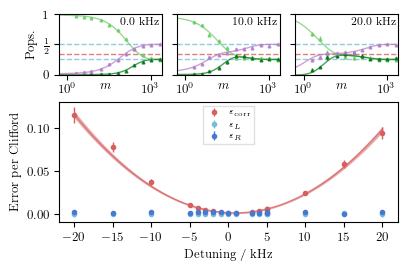

In [9]:

x_fit = np.linspace(min(errs), max(errs), 100)
I_fit = detuning_model(x_fit*2*np.pi, *popt)
fig_width = gs.get_fig_width()*0.75
fig_height = gs.get_fig_width()*0.75/1.618

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(fig_width, fig_height))
grids = GridSpec(2, 3, figure=fig, height_ratios=[1, 2], wspace=0.15, hspace=0.3)
axa = fig.add_subplot(grids[0, 0])
axb = fig.add_subplot(grids[0, 1], sharey=axa)
axc = fig.add_subplot(grids[0, 2], sharey=axa)
ax1 = fig.add_subplot(grids[1, :])

ax1.errorbar(errs, [t[0] for t in param1], yerr=[t[1] for t in param1], fmt="o", label="$\\varepsilon_\\mathrm{corr}$", color=gs.get_color(2))
ax1.errorbar(errs, [t[0] for t in param2], yerr=[t[1] for t in param2], fmt="o", label="$\\varepsilon_L$", color=gs.get_color(5))
ax1.errorbar(errs, [t[0] for t in param3], yerr=[t[1] for t in param3], fmt="o", label="$\\varepsilon_R$", color=gs.get_color(6))
ax1.plot(x_fit, I_fit, color=gs.get_color(2), alpha=gs.get_alpha(), linestyle="-")
# plot error bars for the fit by shading the area between the upper and lower bounds of the fit using MC method
# best-fit parameters and covariance from your fit
# draw correlated parameter samples
n_samples = 5000
param_samples = np.random.multivariate_normal(popt, pcov, size=n_samples)

# evaluate model for each sample
y_samples = np.array([detuning_model(x_fit*2*np.pi, *p) for p in param_samples])

# central 68% band, roughly 1-sigma
y_lo = np.percentile(y_samples, 16, axis=0)
y_hi = np.percentile(y_samples, 84, axis=0)

plt.fill_between(x_fit, y_lo, y_hi, alpha=0.4, color=gs.get_color(2))

# print(f"Mean fitted theta_diff: {theta_diff_0:.4f} ± {theta_diff_0_std:.4f}")
# ax1.hlines(theta_diff_0, min(errs), max(errs), color=gs.get_color(5), linestyle="--", alpha=0.8)
# # plot error bars for the mean by shading the area between the upper and lower bounds
# ax1.fill_between(x_fit, [theta_diff_0 - theta_diff_0_std]*len(x_fit), [theta_diff_0 + theta_diff_0_std]*len(x_fit), color=gs.get_color(5), alpha=0.2)

ax1.set_ylabel("Error per Clifford")

#gs.place_letter(fig, "c")

ax1.set_xlabel("Detuning / kHz")
ax1.legend(loc="upper center")

# select low and high detuning points and plot the RB decay curves with fits
low_ind = np.argmin(abs(errs))
high_ind = np.argmax(errs)
med_ind = np.argsort(abs(errs))[int(len(errs)/1.5)]
med_high_ind = np.argsort(abs(errs))[int(len(errs)/1.25)]

low_rid = rids[low_ind]
low_err = errs[low_ind]
high_rid = rids[high_ind]
high_err = errs[high_ind]
med_rid = rids[med_ind]
med_err = errs[med_ind]

med_high_rid = rids[med_high_ind]
med_high_err = errs[med_high_ind]

low_df, low_popt, low_pcov = m.rb_to_fits(date, low_rid, sim_outcomes)
high_df, high_popt, high_pcov = m.rb_to_fits(date, high_rid, sim_outcomes)
med_df, med_popt, med_pcov = m.rb_to_fits(date, med_rid, sim_outcomes)
med_high_df, med_high_popt, med_high_pcov = m.rb_to_fits(date, med_high_rid, sim_outcomes)

for ax, df, popt_i, err in zip([axa, axb, axc], [low_df, med_df, high_df], [low_popt, med_popt, high_popt], [low_err, med_err, high_err]):
    plot_data_fit(ax, df, m, popt_i)
    ax.text(0.98, 0.95, f"{err:.1f} kHz", transform=ax.transAxes, verticalalignment="top", color="black", horizontalalignment="right", fontsize=8)
    ax.grid(False)

# remove y labels for the upper plots
axa.set_yticks([0., 0.5, 1.0])
axa.set_yticklabels(["0", "$\\frac{1}{2}$", "1"])
plt.setp(axb.get_yticklabels(), visible=False)
plt.setp(axc.get_yticklabels(), visible=False)
# remove y title
axb.set_ylabel("")
axc.set_ylabel("")
ax1.grid(False)


#save the figure
f_path = "..\\..\\pdf_figure\\ch4\\detuning_scan.pdf"
# UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
fig.savefig(f_path, bbox_inches="tight")


In [ ]:
# select low and high detuning points and plot the RB decay curves with fits
low_ind = np.argmin(errs)
high_ind = np.argmax(errs)
med_ind = np.argsort(abs(errs))[int(len(errs)/1.5)]
med_high_ind = np.argsort(abs(errs))[int(len(errs)/1.25)]

low_rid = rids[low_ind]
low_err = errs[low_ind]
high_rid = rids[high_ind]
high_err = errs[high_ind]
med_rid = rids[med_ind]
med_err = errs[med_ind]

med_high_rid = rids[med_high_ind]
med_high_err = errs[med_high_ind]

m = fh.GTReducedModel()
m= fh.GTModel()
low_df, low_popt, low_pcov = m.rb_to_fits(date, low_rid, sim_outcomes)
high_df, high_popt, high_pcov = m.rb_to_fits(date, high_rid, sim_outcomes)
med_df, med_popt, med_pcov = m.rb_to_fits(date, med_rid, sim_outcomes)
med_high_df, med_high_popt, med_high_pcov = m.rb_to_fits(date, med_high_rid, sim_outcomes)



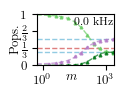

In [26]:

fig_width = gs.get_fig_width()*246/510*1/3
fig_height = gs.get_fig_width()*246/510*1/4
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")

plot_data_fit(ax, low_df, m, low_popt)
ax.text(0.98, 0.95, f"{low_err:.1f} kHz", transform=ax.transAxes, verticalalignment="top", color="black", horizontalalignment="right", fontsize=8)
f_path = f"..\\pdf_figure\\f3_inset_{low_err}.pdf"
ax.grid(False)
fig.savefig(f_path,  bbox_inches = "tight", transparent=True)

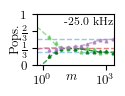

In [27]:
fig_width = gs.get_fig_width()*246/510*1/3
fig_height = gs.get_fig_width()*246/510*1/4
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")
plot_data_fit(ax, high_df, m, high_popt)
ax.text(0.98, 0.95, f"{high_err:.1f} kHz", transform=ax.transAxes, verticalalignment="top", color="black", horizontalalignment="right", fontsize=8)
f_path = f"..\\pdf_figure\\f3_inset_{high_err}.pdf"
ax.grid(False)
fig.savefig(f_path,  bbox_inches = "tight", transparent=True)

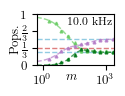

In [28]:
fig_width = gs.get_fig_width()*246/510*1/3
fig_height = gs.get_fig_width()*246/510*1/4
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")
plot_data_fit(ax, med_df, m, med_popt)
ax.text(0.98, 0.95, f"{med_err:.1f} kHz", transform=ax.transAxes, verticalalignment="top", color="black", horizontalalignment="right", fontsize=8)
f_path = f"..\\pdf_figure\\f3_inset_{med_err}.pdf"
ax.grid(False)
fig.savefig(f_path,  bbox_inches = "tight", transparent=True)

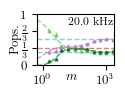

In [29]:
fig_width = gs.get_fig_width()*246/510*1/3
fig_height = gs.get_fig_width()*246/510*1/4
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(fig_width, fig_height), layout="constrained")
plot_data_fit(ax, med_high_df, m, med_high_popt)
ax.text(0.98, 0.95, f"{med_high_err:.1f} kHz", transform=ax.transAxes, verticalalignment="top", color="black", horizontalalignment="right", fontsize=8)
f_path = f"..\\pdf_figure\\f3_inset_{med_high_err}.pdf"
ax.grid(False)
fig.savefig(f_path,  bbox_inches = "tight", transparent=True)